In [1]:
# Handle data path
from pathlib import Path

# Read and display data from Physionet
import wfdb
import pprint
import collections
from IPython.display import clear_output

# Data manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import resample
from scipy.signal import butter,filtfilt

# Divide data into train and test set and save to HDF5
import h5py
import os
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Over and undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from tqdm.notebook import tqdm
import cv2
from tqdm.notebook import tqdm

In [2]:
data_dir = Path('./data/2D_BW')
os.makedirs(data_dir, exist_ok=True)

# directory that store original MIT-BIH data

img_dir = data_dir / 'img'
os.makedirs(img_dir, exist_ok=True)

label_dir = data_dir / 'label'
os.makedirs(label_dir, exist_ok=True)



In [3]:
# Convert training images to nparray
# Convert png files in a directory into the destination nparray
def pngConverter (destination, image_dir, if_red_dim):
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root,file)
                img = cv2.imread(file_path)
            if if_red_dim:
                img = np.mean(img, axis = 2)
            destination.append(img)
            
train_record_list = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
test_record_list = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213,214, 219, 221, 222, 228, 231, 232, 233, 234]

In [4]:
train_image = []
train_label = []
test_image = []
test_label = []
train_or_test = True

for record_number in tqdm(train_record_list, total = len(train_record_list)):
    image_dir = img_dir / str(record_number)
    pngConverter(train_image, image_dir, True)
    label_str = str(record_number)+'.csv'
    label_path = label_dir / label_str
    train_label.append(np.genfromtxt(label_path,delimiter = ','))



  0%|          | 0/22 [00:00<?, ?it/s]

In [5]:
# Ratio Split Helper Function
import math
def train_val_split (data_set, label_set, val_ratio = 0.2, shuffle = True):

    n = len(data_set)
    label_count = [[] for _ in range(4)]

    if shuffle:
        index = np.random.permutation(n)
    else:
        index = np.arange(n)
    
    data_set =  [data_set[idx] for idx in index]
    label_set = [label_set[idx] for idx in index]

    for idx, label in enumerate(label_set):
        if label != 4:
            label_count[int(label)].append(idx)

    train_idx = []
    val_idx = []

    for i in range(len(label_count)):
        current_count = len(label_count[i])
        print("current label is %d with count %d" % (i, current_count))
        split_idx = math.ceil(current_count * val_ratio)
        train_idx = train_idx + label_count[i][split_idx:]
        val_idx = val_idx + label_count[i][:split_idx]
    
    return [data_set[idx] for idx in train_idx], [label_set[idx] for idx in train_idx], [data_set[idx] for idx in val_idx], [label_set[idx] for idx in val_idx]


train_label_flattened = []
for i in range(len(train_label)):
    for j in range(len(train_label[i])):
        train_label_flattened.append(train_label[i][j])
        
exp_train_image, exp_train_label, exp_val_image, exp_val_label = train_val_split(train_image, train_label_flattened)


current label is 0 with count 45801
current label is 1 with count 942
current label is 2 with count 3786
current label is 3 with count 414


In [6]:
pip install scikit-image


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from skimage.transform import rotate
from skimage.util import random_noise
import random
import numpy as np



def data_aug_safe(train_image, train_label, ratio=0.25):
    # 1. Organize data by class
    class_data = {}
    for img, label in zip(train_image, train_label):
        label = int(label)
        if label not in class_data:
            class_data[label] = []
        class_data[label].append(img)
    
    max_count = max(len(images) for images in class_data.values())
    target_count = int(max_count * ratio) # Target is 25% of the biggest class
    
    print(f"🛡️ Safe Balancing: Majority is {max_count}. Boosting others to {target_count}.")
    
    final_images = []
    final_labels = []
    
    for label, images in class_data.items():
        current_count = len(images)
        
        # Determine if this class needs boosting
        if current_count < target_count:
            needed = target_count - current_count
            print(f"   Class {label}: Generating {needed} new samples (Target: {target_count})...")
        else:
            needed = 0
            print(f"   Class {label}: Already has {current_count} (Enough).")
        
        final_images.extend(images)
        final_labels.extend([label] * current_count)
        
        # Generate NEW images (only if needed)
        if needed > 0:
            for _ in range(needed):
                base_img = random.choice(images)
                aug_type = random.choice(['rotate', 'flip', 'noise'])
                
                if aug_type == 'rotate':
                    angle = random.choice([90, 180, 270, random.randint(-20, 20)])
                    new_img = rotate(base_img, angle, mode='edge')
                elif aug_type == 'flip':
                    if random.random() > 0.5:
                        new_img = np.flipud(base_img)
                    else:
                        new_img = np.fliplr(base_img)
                elif aug_type == 'noise':
                    new_img = random_noise(base_img, mode='gaussian', var=0.005)
                
                final_images.append(new_img)
                final_labels.append(label)

    return final_images, final_labels

In [ ]:
print("Initial Train set length is %d" % (len(exp_train_image)))
print("Validation set length is %d" % (len(exp_val_image)))

aug_img, aug_label = data_aug_safe(exp_train_image, exp_train_label, ratio=0.25)

# Shuffle the new balanced dataset
index = np.random.permutation(len(aug_img))
aug_img =  [aug_img[idx] for idx in index]
aug_label = [aug_label[idx] for idx in index]

print(f"Final Balanced Dataset Size: {len(aug_img)}")
print(f"Final Label Count: {len(aug_label)}")

Initial Train set length is 40752
Validation set length is 10191
🛡️ Safe Balancing: Majority is 36640. Boosting others to 9160.
   Class 0: Already has 36640 (Enough).
   Class 1: Generating 8407 new samples (Target: 9160)...
   Class 2: Generating 6132 new samples (Target: 9160)...
   Class 3: Generating 8829 new samples (Target: 9160)...
Final Balanced Dataset Size: 64120
Final Label Count: 64120


In [4]:
from torch import nn
from scipy.stats import truncnorm
from torch.nn.parameter import Parameter
import torch.optim as optim
from torch.autograd import Variable
import torch
import h5py
from pathlib import Path

In [ ]:


# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# a generator for batches of data
# yields data (batchsize) and labels (batchsize)
# if shuffle is True, it will load batches in a random order
def DataBatch(data, label, batchsize, shuffle=True):
    n = len(data)
    if shuffle:
        index = np.random.permutation(n)
    else:
        index = np.arange(n)
    for i in range(int(np.ceil(n/batchsize))):
        inds = index[i*batchsize : min(n,(i+1)*batchsize)]
        yield [data[idx] for idx in inds], [label[idx] for idx in inds]

# evaluate method for cnn
def eval_cnn(model, test_data, test_label, minibatch = 100, n=4):
    correct=0.
    M = np.zeros((n,n))

    for i, (data,label) in enumerate(DataBatch(test_data,test_label,minibatch,shuffle=False)):
        data = Variable(torch.FloatTensor(np.asarray(data)))
        data = data.unsqueeze(1)
        data = data.to(torch.device("cuda"))
        labels = Variable(torch.LongTensor(np.asarray(label)))
        labels = labels.to(torch.device("cuda"))
        prediction = model.forward(data)
        with torch.no_grad():
            numpy_pred = prediction.cpu().numpy()
            batch_pred = np.argmax(numpy_pred, axis=1)
            correct += np.sum(batch_pred==label)
        
            for j in range(len(label)):
                M[int(label[j]),int(batch_pred[j])] += 1

    for i in range(n):
        M[i,:] /= np.sum(M[i,:])
      
    acc = correct/len(test_data)*100
    print('Test accuracy is %f' % (acc))
    return M, acc


# helper function to initialize weight variable
def weight_variable(shape):
    initial = torch.Tensor(truncnorm.rvs(-1/0.01, 1/0.01, scale=0.01, size=shape))
    return Parameter(initial, requires_grad=True)

# helper function to initialize bias variable
def bias_variable(shape):
    initial = torch.Tensor(np.ones(shape)*0.1)
    return Parameter(initial, requires_grad=True)


In [12]:
def train_net(model, trainData, trainLabels, valData, valLabels, epochs=10, learnRate = 1e-4, batchSize=50, weights = None):
        
        if weights:
            class_weights = torch.FloatTensor(weights).cuda()
            criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr = learnRate)

        train_loss = []
        val_loss = []
        train_accuracy = []
        test_accuracy = []
        
        
        for epoch in tqdm(range(epochs)):
            model.to(torch.device("cuda"))
            model.train()  # set network in training mode
            epoch_train_loss = []
            epoch_val_loss = []

            for i, (data,labels) in enumerate(DataBatch(trainData, trainLabels, batchSize, shuffle=True)):
                data = Variable(torch.FloatTensor(np.asarray(data)))
                data = data.unsqueeze(1)
                data = data.to(torch.device("cuda"))
                labels = Variable(torch.LongTensor(np.asarray(labels)))
                labels = labels.to(torch.device("cuda"))
                
                # Now train the model using the optimizer and the batch data
                prediction = model.forward(data)
                loss = criterion(prediction, labels)
                epoch_train_loss.append(loss.item())
                # print('Epoch %d Batch number %d loss: %f' % (epoch+1, i, np.mean(np.array(epoch_train_loss))))
                model.zero_grad()
                loss.backward()
                optimizer.step()

            model.to(torch.device("cuda"))
            model.eval()  # set network in evaluation mode
            # validation loss
            for i, (val_data, val_labels) in enumerate(DataBatch(valData, valLabels, batchSize, shuffle=False)):
                val_data = Variable(torch.FloatTensor(np.asarray(val_data)))
                val_data = val_data.unsqueeze(1)
                val_data = val_data.to(torch.device("cuda"))
                val_labels = Variable(torch.LongTensor(np.asarray(val_labels)))
                val_labels = val_labels.to(torch.device("cuda"))
                with torch.no_grad():
                    prediction = model.forward(val_data)
                    loss = criterion(prediction, val_labels)
                    epoch_val_loss.append(loss.item())

            epoch_mean_val_loss = np.mean(np.array(epoch_val_loss))
            val_loss.append(epoch_mean_val_loss)
                
            epoch_mean_train_loss = np.mean(np.array(epoch_train_loss))
            train_loss.append(epoch_mean_train_loss)
            
        print ('Epoch:%d train loss: %f val loss: %f'%(epoch+1, epoch_mean_train_loss, epoch_mean_val_loss))
        
        return train_loss, val_loss

In [13]:
import torchvision.models as models
resnet18 = models.resnet18(pretrained=True)
resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3,bias=False)
resnet18.fc = nn.Linear(512, 4)


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
print(resnet18)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [15]:
train_loss, val_loss = train_net(resnet18, aug_img, aug_label, exp_val_image, exp_val_label, epochs=10, batchSize=128)
torch.save(resnet18.state_dict(), Path('./model/exp_resnet18_pretrained_aug.pt'))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch:10 train loss: 0.139167 val loss: 0.046826


# Test model



In [5]:
# Handle data path
from pathlib import Path

# Read and display data from Physionet
import wfdb
import pprint
import collections
from IPython.display import clear_output

# Data manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import resample
from scipy.signal import butter,filtfilt

# Divide data into train and test set and save to HDF5
import h5py
import os
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Over and undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

from tqdm.notebook import tqdm
import cv2
from tqdm.notebook import tqdm

from torch import nn
from scipy.stats import truncnorm
from torch.nn.parameter import Parameter
import torch.optim as optim
from torch.autograd import Variable
import torch

In [6]:
data_dir = Path('./data/2D_BW')
os.makedirs(data_dir, exist_ok=True)

# directory that store original MIT-BIH data

img_dir = data_dir / 'img'
os.makedirs(img_dir, exist_ok=True)

label_dir = data_dir / 'label'
os.makedirs(label_dir, exist_ok=True)

# Convert training images to nparray
# Convert png files in a directory into the destination nparray
def pngConverter (destination, image_dir, if_red_dim):
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.endswith('.png'):
                file_path = os.path.join(root,file)
                img = cv2.imread(file_path)
            if if_red_dim:
                img = np.mean(img, axis = 2)
            destination.append(img)
            
train_record_list = [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
test_record_list = [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213,214, 219, 221, 222, 228, 231, 232, 233, 234]

In [7]:
test_label = []
test_image = []

for record_number in tqdm(test_record_list, total = len(test_record_list)):
    image_dir = img_dir / str(record_number)
    pngConverter(test_image, image_dir, True)
    label_str = str(record_number)+'.csv'
    label_path = label_dir / label_str
    test_label.append(np.genfromtxt(label_path,delimiter = ','))

test_label_flattened = []
for i in range(len(test_label)):
    for j in range(len(test_label[i])):
        test_label_flattened.append(test_label[i][j])

  0%|          | 0/22 [00:00<?, ?it/s]

In [8]:
label_arr = np.array(test_label_flattened)
index = np.where(np.array(label_arr) == 4)[0]

In [9]:
test_label_flattened = [i for j, i in enumerate(test_label_flattened) if j not in index]
test_image = [i for j, i in enumerate(test_image) if j not in index]

In [10]:
print(np.unique(test_label_flattened))

[0. 1. 2. 3.]


In [11]:
print(len(test_image), test_image[0].shape)

49644 (224, 224)


In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def DataBatch(data, label, batchsize, shuffle=True):
    n = len(data)
    if shuffle:
        index = np.random.permutation(n)
    else:
        index = np.arange(n)
    for i in range(int(np.ceil(n/batchsize))):
        inds = index[i*batchsize : min(n,(i+1)*batchsize)]
        yield [data[idx] for idx in inds], [label[idx] for idx in inds]

def test_model(model, test_data, test_label, batch_size=64):
    """
    Optimized version: Runs model once per batch and returns:
        - classification report string
        - dictionary of classification report
        - confusion matrix
    """
    
    predictions = []
    labels_list = []
    
    model.to(device)
    model.eval() # Ensure model is in evaluation mode
    
    print("Running Test...")
    
    with torch.no_grad(): # Disable gradient calculation for speed
        for i, (data, label) in enumerate(DataBatch(test_data, test_label, batch_size, shuffle=False)):
            
            # 1. Prepare Data
            data = Variable(torch.FloatTensor(np.asarray(data)))
            data = data.unsqueeze(1).to(device)
            
            # 2. Run Model (THE FIX: We run this ONCE and save it)
            outputs = model(data)
            
            # 3. Get Predictions from the saved output
            # argmax(1) finds the index of the highest score
            preds = np.argmax(outputs.cpu().numpy(), axis=1)
            
            predictions += list(preds)
            labels_list += list(label)
            
    # Convert lists to numpy arrays for Scikit-Learn
    predictions = np.array(predictions)
    labels_arr = np.array(labels_list)
        
    target_names = ['N', 'S', 'V', 'F']
    
    # Generate the requested reports
    report = classification_report(labels_arr, predictions, target_names=target_names, digits=3)
    report_dict = classification_report(labels_arr, predictions, target_names=target_names, output_dict=True)
    c_matrix = confusion_matrix(labels_arr, predictions)
    
    return report, report_dict, c_matrix
resnet18 = models.resnet18(pretrained=False)
resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3,bias=False)
resnet18.fc = nn.Linear(512, 4)
resnet18.load_state_dict(torch.load(Path('./model/exp_resnet18_pretrained_aug.pt')))
resnet18.eval()

report, report_dict, c_matrix = test_model(resnet18, test_image, test_label_flattened)

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Running Test...


In [13]:
print('Training result:\n', report)

Training result:
               precision    recall  f1-score   support

           N      0.954     0.948     0.951     44200
           S      0.342     0.115     0.172      1837
           V      0.573     0.884     0.695      3219
           F      0.084     0.036     0.050       388

    accuracy                          0.906     49644
   macro avg      0.488     0.496     0.467     49644
weighted avg      0.900     0.906     0.899     49644



Normalized confusion matrix


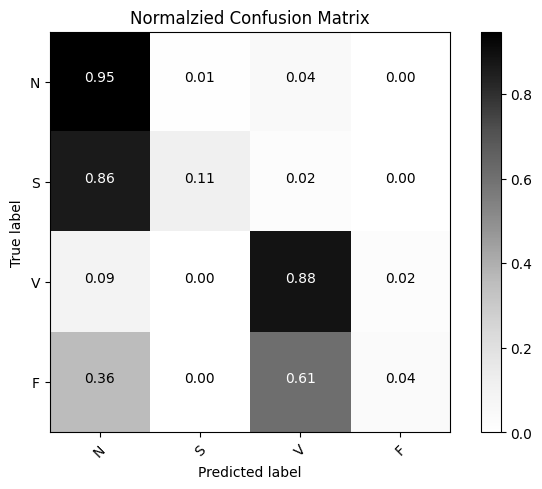

<Figure size 640x480 with 0 Axes>

In [14]:
import itertools

## display confusion matrix
display_labels = ['N', 'S', 'V', 'F']

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    plt.clf()
    
plot_confusion_matrix(c_matrix, display_labels ,
                      title='Normalzied Confusion Matrix', normalize=True, cmap='Greys')
